In [1]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/iris01.csv")
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [3]:
t1 = dict(zip(df.columns, ['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이', '종류']))

In [4]:
df1 = df.rename(columns=t1)

In [5]:
df1['종류'].value_counts()

종류
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
df1.dtypes

꽃받침길이    float64
꽃받침넓이    float64
꽃잎길이     float64
꽃잎넓이     float64
종류        object
dtype: object

In [7]:
conditions = [
    df['species'] == 'setosa', 
    df['species'] == 'versicolor', 
    df['species'] == 'virginica'
]

choices = [0, 1, 2]

In [8]:
import numpy as np
df1['종류'] = np.select(conditions, choices, default=-1)

In [9]:
# t1 = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
# df1['종류'] = df1['종류'].map(t1)

In [10]:
df1.dtypes

꽃받침길이    float64
꽃받침넓이    float64
꽃잎길이     float64
꽃잎넓이     float64
종류         int64
dtype: object

In [11]:
x = df1[['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이']].values
y = df1['종류'].values
x.shape, y.shape

((150, 4), (150,))

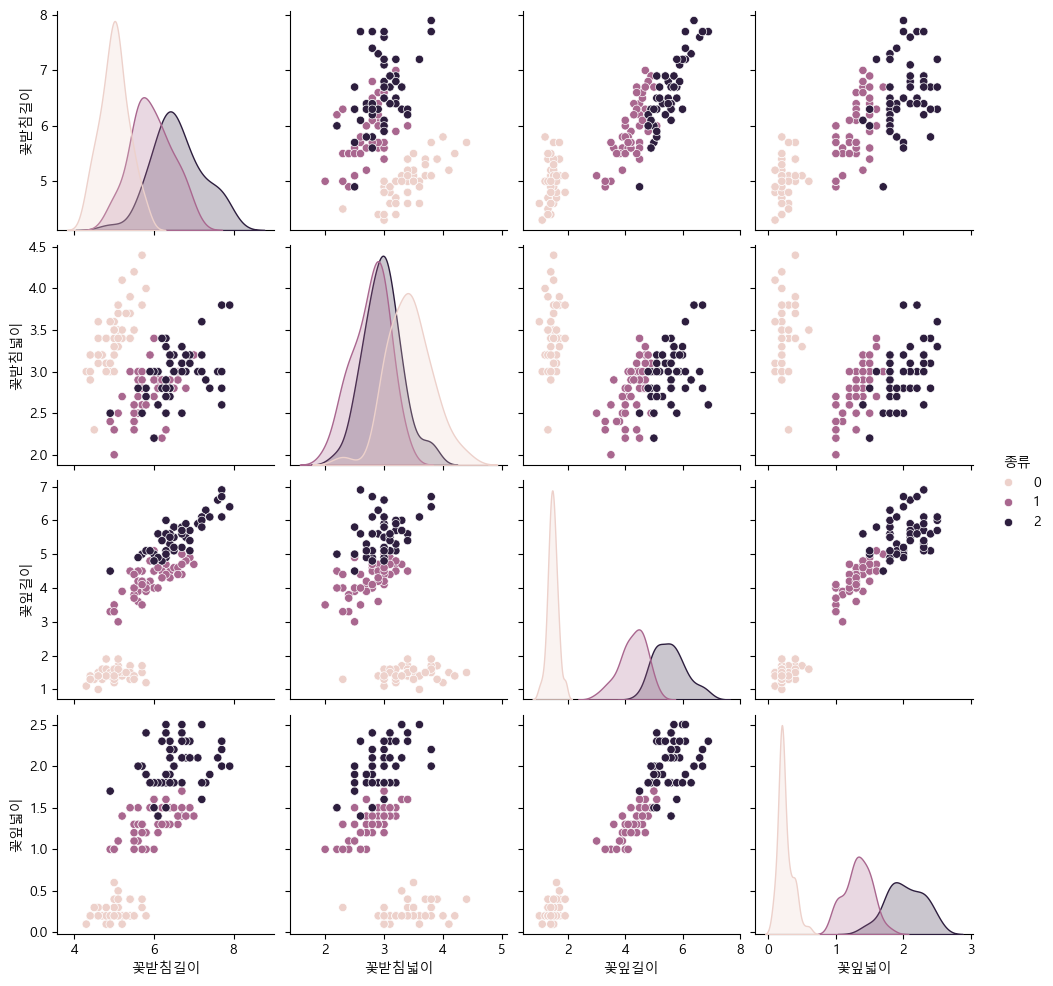

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_cjk import patch
patch()

sns.pairplot(data=df1, hue='종류')
plt.show()

In [16]:
x2 = df1[['꽃받침길이', '꽃잎길이', '꽃잎넓이']].values
y2 = df1['종류'].values
x2.shape, y2.shape

((150, 3), (150,))

In [17]:
from sklearn.model_selection import train_test_split
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, train_size=0.8)
x2_train.shape, x2_test.shape, y2_train.shape, y2_test.shape

((120, 3), (30, 3), (120,), (30,))

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x2_train_scaled = scaler.fit_transform(x2_train)
x2_test_scaled = scaler.transform(x2_test)
x2_train_scaled.shape, x2_test_scaled.shape

((120, 3), (30, 3))

In [19]:
from sklearn.linear_model import LogisticRegression

lr2 = LogisticRegression()
lr2.fit(x2_train_scaled, y2_train)
lr2.score(x2_train_scaled, y2_train), lr2.score(x2_test_scaled, y2_test)

(0.9583333333333334, 0.9666666666666667)

In [29]:
# 8:2 분할하기
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

# scaler적용
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled.shape, x_test_scaled.shape

# 모델 생성 및 학습
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)
lr.score(x_train_scaled, y_train), lr.score(x_test_scaled, y_test)

# 모델 평가
y_pred = lr.predict(x_test_scaled)
y_pred, y_test

(array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
        0, 2, 0, 0, 0, 2, 2, 0]),
 array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2,
        0, 2, 0, 0, 0, 2, 2, 0]))

In [ ]:
import numpy as np
np.argmax(y_pred)

In [36]:
# 모델저장하기
from sklearn.pipeline import Pipeline
import joblib

pipe = Pipeline([
    ('scaler', scaler),
    ('model', lr),
])
joblib.dump(pipe, './pkl/20260526_multi_classification_botanic.joblib')

['./pkl/20260526_multi_classification_botanic.joblib']